In [1]:
include("BarrierSynthesis.jl")
# include("PlotBarriers.jl")

get_random_multi (generic function with 1 method)

In [2]:
@polyvar u[1:2]
@polyvar(x[1:6]) # x[1] is x, x[2] is y, x[3] is vel, x[4] is θ, x[5] is ω, x[6] is error
    dynamics = [
        (ctrl -> [x[3]*(2.0/π)*(x[4] + π/2.0)-0.2x[6],x[3]*(-2.0/π)*(x[4]+π)-0.2x[6], ctrl[1], x[5], ctrl[2], 0.]),
        (ctrl -> [x[3]*(2.0/π)*(x[4] + π/2.0)-0.2x[6],x[3]*(2.0/π)*x[4]+0.2x[6], ctrl[1], x[5], ctrl[2], 0]),
        (ctrl -> [x[3]*(-2.0/π)*(x[4] - π/2.0)+0.2x[6],x[3]*(2.0/π)*x[4]+0.2x[6], ctrl[1], x[5], ctrl[2], 0]),
        (ctrl -> [x[3]*(-2.0/π)*(x[4] - π/2.0)+0.2x[6],x[3]*(-2.0/π)*(x[4]-π)-0.2x[6], ctrl[1], x[5], ctrl[2], 0]),
    ]
g = 0.1^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin
# Tight reachable-domain approximation for realistic low-curvature controls.
bounds = [[-25., 25.], [-25., 25.], [-3.0,3.0],[-π,π], [-0.25,0.25],[-0.2,0.2]]

6-element Vector{Vector{Float64}}:
 [-25.0, 25.0]
 [-25.0, 25.0]
 [-3.0, 3.0]
 [-3.141592653589793, 3.141592653589793]
 [-0.25, 0.25]
 [-0.2, 0.2]

In [3]:
# λ = 1
K = 0.1
δ = 0.1
ϵ = 0.02
α = 0.6
max_degree=2

# realistic control grid
control_vals1 = [-2.0, -1.0, 0.0, 1.0, 2.0]
control_vals2 = [−0.015, −0.0075, 0.0, 0.0075, 0.015] 
U = [[u1, u2] for u1 in control_vals1 for u2 in control_vals2]

n_tests = 650

650

In [4]:
test_pts = [ get_random(bounds, g) for _ in 1:n_tests ]

650-element Vector{Vector{Float64}}:
 [-2.8612240638895656, -17.118582135176897, -2.0325928868884375, 2.864766046514105, 0.10684804758229138, 0.022729769332451383]
 [1.710137717328248, 20.69582926017486, -1.1961848431749331, 0.9557539555101764, -0.20113521756441882, 0.16263631502848436]
 [-1.4139644768962611, -0.4572317080626398, 2.6420423935439397, 1.158161094168248, -0.153930042530241, -0.19908293952569506]
 [-16.14097622932747, 11.158998213688925, 0.25791861192134435, 1.469268940525212, 0.165375101282296, -0.05705573799135241]
 [24.53160645313065, 14.677792056153592, 2.86141421439158, -2.7906502452491546, 0.10783133905124348, 0.01297317539270676]
 [-23.50582873470053, 3.804484649625895, 1.7564976574218658, -0.7726996118702862, 0.1238936309790642, -0.015989720729429335]
 [9.31141823043199, 10.722267158402737, 0.47486091510304407, -2.809830706594539, 0.035481614954138374, -0.038834839285670636]
 [-8.494833996709751, 15.619647861907886, 1.2730777857915552, 2.397105792841627, -0.0855433

In [5]:
function findRepulsiveBarrier_HybridCT(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4, ϵ=1.0, τ=0.1, γ=10.0, K=1.0, δ=1.0, α=1.0, state_bounds=bounds, nominal_pts=nothing, nominal_margin=-0.01)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set((var - lb) * (ub - var) >= 0)
        return dom
    end

    @assert τ > 0.0 "τ must be positive."
    @assert δ > 0.0 "δ must be positive."
    @assert K >= 0.0 "K must be nonnegative."
    @assert α > 0.0 "α must be positive."
    @assert iseven(max_degree) "max_degree must be even for SOS-based synthesis."

    λ = (1.0 / τ) * log(1.0 + K / δ)

    solver = optimizer_with_attributes(MosekTools.Optimizer, MOI.Silent() => true)
    model = SOSModel(solver)
    monos = monomials(x, 0:max_degree)
    N = length(monos)
    @variable(model, -γ <= c[1:N] <= γ)
    B = polynomial(c[1:end], monos)

    dom_list = prepare_domain(x, state_bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $D")

    # 1) Unsafe-set positivity on obstacle states (g >= 0 denotes the obstacle interior)
    @constraint(model, B >= ϵ, domain = D ∩ @set(g >= 0))

    # 1b) Keep key nominal lazy8 states inside certified-safe side to reduce trajectory conservatism.
    if nominal_pts !== nothing && !isempty(nominal_pts)
        for pt in nominal_pts
            @constraint(model, B(pt...) <= nominal_margin)
        end
    end

    # 2) Decrease condition under each hybrid mode and fixed control
    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[4], (i - 3) * π / 2, (i - 2) * π / 2)
        @constraint(model, dBdt <= λ * B, domain = D ∩ dom_i)
    end

    # 3) Bounded-jump condition: B(y - yo, z) - B(y, z) <= K for yo in obstacle set
    @polyvar q1 q2
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    @constraint(model, K >= B_shift - B, domain = D ∩ Qα)

    set_objective_sense(model, MOI.MIN_SENSE)
    objective_fn = sum((B(pt...) for pt in test_pts); init=0.0)
    @objective(model, Min, objective_fn)

    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")
    if stat != FEASIBLE_POINT
        return missing
    end

    return value(B), K
end

findRepulsiveBarrier_HybridCT (generic function with 1 method)

In [6]:
function synthesize_barriers_over_controls(U, x, g, dynamics, test_pts; max_degree=2, ϵ=0.02, K=0.1, δ=0.1, α=0.6)
    @assert iseven(max_degree) "max_degree must be even for SOS-based synthesis."

    pts_work = copy(test_pts)
    results = NamedTuple[]
    cumulative_time = 0.0

    # Synthesize gentler controls first; this often yields less conservative cascades.
    ordered = sort(collect(enumerate(U)), by=tup -> norm(Float64.(tup[2])))

    for (k, (i, u_i)) in enumerate(ordered)
        ctrl = Float64.(u_i)
        println("Synthesizing barrier $(k)/$(length(U)) for u = ", ctrl, " (orig idx=", i, ")")
        t_start = time()
        res_i = findRepulsiveBarrier_HybridCT(
            x, ctrl, g, dynamics, pts_work;
            max_degree=max_degree, ϵ=ϵ, K=K, δ=δ, α=α,
        )
        elapsed = time() - t_start
        cumulative_time += elapsed
        if res_i === missing
            println("  -> synthesis failed, skipping this control (elapsed=", round(elapsed, digits=3), " s, cumulative=", round(cumulative_time, digits=3), " s)")
            continue
        end

        B_i, K_i = res_i
        push!(results, (idx=i, u=(ctrl[1], ctrl[2]), B=B_i, K=K_i, solve_time=elapsed, cumulative_time=cumulative_time, synth_order=k))
        pts_work = filter!(pt -> B_i(pt...) > 0.0, pts_work)
        println("  -> success, remaining candidate points: ", length(pts_work), " (elapsed=", round(elapsed, digits=3), " s, cumulative=", round(cumulative_time, digits=3), " s)")
    end

    # Keep deterministic order by original control index for downstream readability.
    sort!(results, by=item -> item.idx)
    return results, pts_work
end

required_syms = (:U, :x, :g, :dynamics, :test_pts)
missing_syms = [string(s) for s in required_syms if !isdefined(Main, s)]
if !isempty(missing_syms)
    error("Missing prerequisites: " * join(missing_syms, ", ") * ". Run the initialization cells first.")
end

max_degree_cfg = @isdefined(max_degree) ? max_degree : 2
if !iseven(max_degree_cfg)
    error("max_degree must be even for SOS-based synthesis. Set an even value, got $(max_degree_cfg).")
end

ϵ_cfg = @isdefined(ϵ) ? ϵ : 0.02
K_cfg = @isdefined(K) ? K : 0.1
δ_cfg = @isdefined(δ) ? δ : 0.1
α_cfg = @isdefined(α) ? α : 0.6

synth_start = time()
barrier_data, test_pts = synthesize_barriers_over_controls(
    U, x, g, dynamics, test_pts;
    max_degree=max_degree_cfg, ϵ=ϵ_cfg, K=K_cfg, δ=δ_cfg, α=α_cfg,

 )
synth_elapsed = time() - synth_start

@assert !isempty(barrier_data) "No barriers synthesized from the control grid."

all_barriers = [item.B for item in barrier_data]
barrier_controls_synth = [item.u for item in barrier_data]
all_K = [item.K for item in barrier_data]

println("Synthesized ", length(all_barriers), " barriers out of ", length(U), " controls.")
println("Total synthesis wall time: ", round(synth_elapsed, digits=3), " s")
println("Cumulative solve times for computed barriers:")
for item in sort(barrier_data, by=r -> r.synth_order)
    println("  order=", item.synth_order, ", idx=", item.idx, ", u=", item.u, ", solve=", round(item.solve_time, digits=3), " s, cumulative=", round(item.cumulative_time, digits=3), " s")
end
display(barrier_controls_synth)

Synthesizing barrier 1/25 for u = [0.0, 0.0] (orig idx=13)
Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 25.0 + x[1] ≥ 0, 25.0 - x[1] ≥ 0, 625.0 - x[1]^2 ≥ 0, 25.0 + x[2] ≥ 0, 25.0 - x[2] ≥ 0, 625.0 - x[2]^2 ≥ 0, 3.0 + x[3] ≥ 0, 3.0 - x[3] ≥ 0, 9.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 0.25 + x[5] ≥ 0, 0.25 - x[5] ≥ 0, 0.0625 - x[5]^2 ≥ 0, 0.2 + x[6] ≥ 0, 0.2 - x[6] ≥ 0, 0.04000000000000001 - x[6]^2 ≥ 0 }
Status obtained: FEASIBLE_POINT
  -> success, remaining candidate points: 650 (elapsed=15.319 s, cumulative=15.319 s)
Synthesizing barrier 2/25 for u = [0.0, -0.0075] (orig idx=12)
Domain: { (x[1], x[2], x[3], x[4], x[5], x[6]) | 25.0 + x[1] ≥ 0, 25.0 - x[1] ≥ 0, 625.0 - x[1]^2 ≥ 0, 25.0 + x[2] ≥ 0, 25.0 - x[2] ≥ 0, 625.0 - x[2]^2 ≥ 0, 3.0 + x[3] ≥ 0, 3.0 - x[3] ≥ 0, 9.0 - x[3]^2 ≥ 0, 3.141592653589793 + x[4] ≥ 0, 3.141592653589793 - x[4] ≥ 0, 9.869604401089358 - x[4]^2 ≥ 0, 0.25 + x[5] ≥ 0, 0.25 - x[5] ≥ 0, 0.0625

25-element Vector{Tuple{Float64, Float64}}:
 (-2.0, -0.015)
 (-2.0, -0.0075)
 (-2.0, 0.0)
 (-2.0, 0.0075)
 (-2.0, 0.015)
 (-1.0, -0.015)
 (-1.0, -0.0075)
 (-1.0, 0.0)
 (-1.0, 0.0075)
 (-1.0, 0.015)
 (0.0, -0.015)
 (0.0, -0.0075)
 (0.0, 0.0)
 (0.0, 0.0075)
 (0.0, 0.015)
 (1.0, -0.015)
 (1.0, -0.0075)
 (1.0, 0.0)
 (1.0, 0.0075)
 (1.0, 0.015)
 (2.0, -0.015)
 (2.0, -0.0075)
 (2.0, 0.0)
 (2.0, 0.0075)
 (2.0, 0.015)

In [7]:
println("Total synthesized barriers: ", length(all_barriers))
display(all_barriers)

Total synthesized barriers: 25


25-element Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}:
 0.019877121907623134 + 1.1569682839093865e-8x₆ - 3.275398625345136e-8x₅ + 1.502677456180139e-9x₄ + 1.543938576898747e-8x₃ + 1.6711538280532123e-8x₂ + 1.0950719050014107e-8x₁ + 7.815399649768832e-6x₆² + 8.424605661647273e-7x₅x₆ + 1.9063475175531588e-6x₅² - 1.3832300054822603e-8x₄x₆ + 2.9205049417049893e-9x₄x₅ + 1.7300735728833932e-8x₄² + 7.995869720388968e-8x₃x₆ + 4.277790165237882e-9x₃x₅ + 2.1973367345988023e-9x₃x₄ + 3.644906044392851e-8x₃² + 5.901390519208211e-8x₂x₆ + 7.129734858241255e-10x₂x₅ + 2.7287197584072507e-9x₂x₄ - 4.234721218276748e-8x₂x₃ - 1.5425826043453243e-5x₂² + 4.240591034822605e-8x₁x₆ - 1.064079475870601e-8x₁x₅ + 2.0362034230879657e-10x₁x₄ - 5.337896570579418e-8x₁x₃ - 2.7181611563924638e-9x₁x₂ - 1.5436071880726197e-5x₁²
 0.019877171038123462 + 2.3866815810413663e-8x₆ - 2.0307795481556776e-8x₅ + 3.698600157566549e-10x₄ + 8.429039438614427e-9x₃ + 2

In [8]:
println("Barrier/control pairs:")
for (j, item) in enumerate(barrier_data)
    println("  ", j, ": u = ", item.u, ", K = ", item.K)
end

Barrier/control pairs:
  1: u = (-2.0, -0.015), K = 0.1
  2: u = (-2.0, -0.0075), K = 0.1
  3: u = (-2.0, 0.0), K = 0.1
  4: u = (-2.0, 0.0075), K = 0.1
  5: u = (-2.0, 0.015), K = 0.1
  6: u = (-1.0, -0.015), K = 0.1
  7: u = (-1.0, -0.0075), K = 0.1
  8: u = (-1.0, 0.0), K = 0.1
  9: u = (-1.0, 0.0075), K = 0.1
  10: u = (-1.0, 0.015), K = 0.1
  11: u = (0.0, -0.015), K = 0.1
  12: u = (0.0, -0.0075), K = 0.1
  13: u = (0.0, 0.0), K = 0.1
  14: u = (0.0, 0.0075), K = 0.1
  15: u = (0.0, 0.015), K = 0.1
  16: u = (1.0, -0.015), K = 0.1
  17: u = (1.0, -0.0075), K = 0.1
  18: u = (1.0, 0.0), K = 0.1
  19: u = (1.0, 0.0075), K = 0.1
  20: u = (1.0, 0.015), K = 0.1
  21: u = (2.0, -0.015), K = 0.1
  22: u = (2.0, -0.0075), K = 0.1
  23: u = (2.0, 0.0), K = 0.1
  24: u = (2.0, 0.0075), K = 0.1
  25: u = (2.0, 0.015), K = 0.1


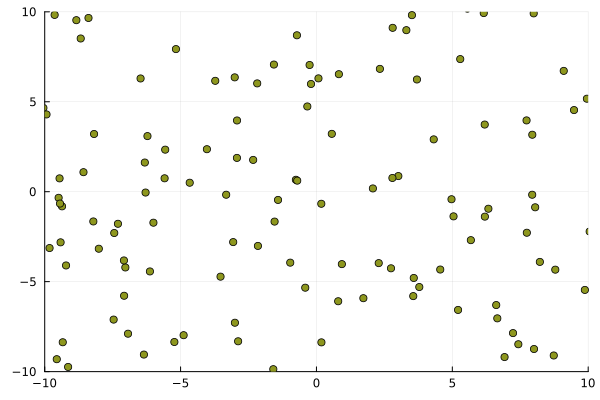

In [9]:
using Plots

function make_contour_plot(B::Polynomial, limits::Tuple{Float64, Float64}, clr; x3_val=0.0, x4_val=0.0, x5_val=0.0, x6_val=0.0)
    x = range(limits[1], limits[2], length=500)
    y = range(limits[1], limits[2], length=500)
    my_fun(xa::Float64, ya::Float64) = B([xa, ya, x3_val, x4_val, x5_val, x6_val])
    z = @. my_fun(x', y)
    contour!(x, y, z, levels=[0.0, 0.01, 0.02], color=clr, colorbar=false)
end

limits = (-10.0, 10.0)
plot(xlims=limits, ylims=limits)

plot_colors = palette(:tab20, max(length(all_barriers), 4))
for (i, B) in enumerate(all_barriers)
    make_contour_plot(B, limits, plot_colors[i])
end

plot!([x1 for (x1, _) in test_pts], [x2 for (_, x2) in test_pts], seriestype=:scatter, labels=false)

In [10]:
using LaTeXStrings
function circleShape(x,y, r)
    θ = LinRange(0, 2*π, 500)
    x .+ r*cos.(θ), y .+ r*sin.(θ)
end
function plot_ics_region(limits::Tuple{Float64,Float64}, all_barriers::Vector{<:Polynomial}; δ = 0.5, x3_val=10, x4_val=π/2,x5_val=1.,x6_val=0.)
    plot(xlims=limits, ylims=limits)
    rectangle(w, h, x, y) = Shape(x .+ [0,w,w,0], y .+ [0,0,h,h])
    pts = vec(collect(Iterators.product(limits[1]:δ:limits[2], limits[1]:δ:limits[2])))
    minB = [minimum(B(px, py, x3_val, x4_val, x5_val, x6_val) for B in all_barriers) for (px, py) in pts]
    has_strict_safe = any(v -> v <= 0.0, minB)
    thresh = 0.0
    fill_color = :green
    fill_label = "B <= 0"
    if !has_strict_safe
        # Fallback for difficult slices: show a near-safe band so the plot is informative.
        sorted_vals = sort(copy(minB))
        idx = max(1, Int(floor(0.08 * length(sorted_vals))))
        thresh = sorted_vals[idx]
        fill_color = :orange
        fill_label = "near-safe"
    end
    for ((px, py), v) in zip(pts, minB)
        if v <= thresh
            plot!(rectangle(δ, δ, px-δ, py-δ), label=false, fill=fill_color, opacity=0.45, linecolor=fill_color)
        end
    end
    plot!(circleShape(0,0,1.), seriestype =[:shape], lw=0.5, c=:black, linecolor=:black, legend=false, aspectratio=1  )
    plot!(xlims=limits, ylims=limits, title="Safe slice (x3=$(round(x3_val, digits=2)), x4=$(round(x4_val, digits=2)), x5=$(round(x5_val, digits=2)); $fill_label)")
end

plot_ics_region (generic function with 1 method)

In [11]:
println("all_barriers count = ", length(all_barriers))
println("barrier_controls_synth count = ", length(barrier_controls_synth))

all_barriers count = 25
barrier_controls_synth count = 25


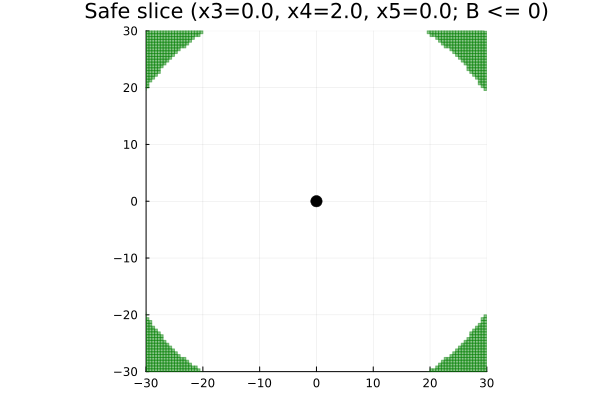

In [12]:
plot_ics_region((-30.0, 30.0), all_barriers; δ = 0.5, x3_val=0.0, x4_val=2.0, x5_val=0.0, x6_val=0.0)

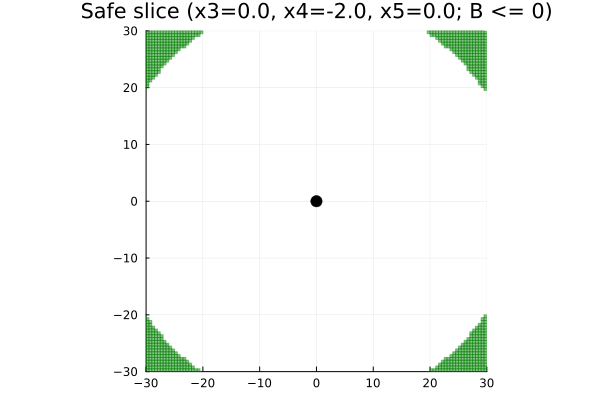

In [13]:
plot_ics_region((-30.0, 30.0), all_barriers; δ = 0.5, x3_val=0.0, x4_val=-2.0, x5_val=0.0, x6_val=0.0)

In [26]:
include("Repulsive_hybrid_CoordTurn_recenter_fix.jl")
using Statistics
using Random

if !@isdefined(all_barriers)
    if @isdefined(barrier_data)
        global all_barriers = [item.B for item in barrier_data]
        println("Recovered all_barriers from barrier_data.")
    else
        error("all_barriers is undefined. Run the barrier synthesis cell first.")
    end
end

if !@isdefined(barrier_controls_synth)
    if @isdefined(barrier_data)
        global barrier_controls_synth = [item.u for item in barrier_data]
        println("Recovered barrier_controls_synth from barrier_data.")
    elseif @isdefined(barrier_controls)
        global barrier_controls_synth = barrier_controls
        println("Recovered barrier_controls_synth from barrier_controls.")
    else
        error("barrier_controls_synth is undefined. Run the barrier synthesis cell first.")
    end
end

barrier_controls = barrier_controls_synth

selected_lazy8_scale = 1.0
if @isdefined(best_scale)
    selected_lazy8_scale = Float64(best_scale)
elseif @isdefined(results_scale) && !isempty(results_scale)
    cfg = @isdefined(scale_acceptance) ? scale_acceptance : (
        max_mean_track=40.0,
        max_max_track=80.0,
        min_clearance=1.2,
        max_override_ratio=0.05,
    )
    passing = filter(
        r -> r.mean_track <= cfg.max_mean_track &&
             r.max_track <= cfg.max_max_track &&
             r.min_dist >= cfg.min_clearance &&
             r.override_ratio <= cfg.max_override_ratio,
        results_scale,
    )
    if !isempty(passing)
        selected_lazy8_scale = maximum(r.scale for r in passing)
    end
end
println("Using lazy8 scale factor in strict main sim = ", selected_lazy8_scale)

base_kwargs = (
    dt=0.05,
    tau_steps=4,
    ref_style=:lazy8,
    ref_start=[-24.0 * selected_lazy8_scale, -24.0 * selected_lazy8_scale],
    ref_end=[24.0 * selected_lazy8_scale, 24.0 * selected_lazy8_scale],
    ref_T=48.0,
    lazy8_center=[0.0, 0.0],
    lazy8_scale=[12.0 * selected_lazy8_scale, 7.0 * selected_lazy8_scale],
    lazy8_cycles=0.65,
    lazy8_phase=-π/2,
    obs_amplitude=7.0,
    obs_lateral_bias=6.0,
    obs_cycles=1.0,
    obs_phase=π/2,
    plot_half_span=max(30.0, 16.0 * selected_lazy8_scale),
    x0=[-10.0, -1.0, 0.0, π/2, 0.0, 0.0],
    T=50.0,
    safety_target=1.2,
    u_track_weight=0.12,
    track_weight=0.08,
    override_weight=1.0,
    safety_weight=100.0,
    delta_eval=0.005,
    unsafe_floor=0.001,
    n_unsafe_probe=500,
    unsafe_r=0.098,
    shift_scale=0.95,
    seed_calib=31,
    runtime_u1min=minimum(control_vals1),
    runtime_u1max=maximum(control_vals1),
    runtime_u2min=minimum(control_vals2),
    runtime_u2max=maximum(control_vals2),
    nominal_speed_gain=1.1,
    nominal_heading_gain=1.8,
    nominal_yaw_gain=2.4,
)

function sample_unsafe_pts(n, r; vlim=8.0, ωlim=0.9, elim=0.4)
    pts = Vector{Vector{Float64}}()
    for _ in 1:n
        ρ = r * sqrt(rand())
        θ = 2π * rand()
        px = ρ * cos(θ)
        py = ρ * sin(θ)
        v = vlim * (2rand() - 1.0)
        ang = π * (2rand() - 1.0)
        omg = ωlim * (2rand() - 1.0)
        err = elim * (2rand() - 1.0)
        push!(pts, [px, py, v, ang, omg, err])
    end
    return pts
end

Random.seed!(base_kwargs.seed_calib)
unsafe_probe_pts = sample_unsafe_pts(base_kwargs.n_unsafe_probe, base_kwargs.unsafe_r)

all_barriers_cal = Polynomial[]
barrier_shift = Float64[]
for B in all_barriers
    unsafe_vals = [B(pt...) for pt in unsafe_probe_pts]
    max_shift = minimum(unsafe_vals) - base_kwargs.unsafe_floor
    s = max(0.0, base_kwargs.shift_scale * max_shift)
    push!(barrier_shift, s)
    push!(all_barriers_cal, B - s)
end

println("Barrier shift stats -> min: ", round(minimum(barrier_shift), digits=5), ", max: ", round(maximum(barrier_shift), digits=5), ", mean: ", round(mean(barrier_shift), digits=5))

delta_grid = [0.003, 0.002, 0.0015, 0.001, 0.0007, 0.0005, 0.0003]
tau_grid = [4, 5]
utrack_grid = [0.10, 0.12]
candidate_overrides = [
    (
        runtime_delta=d,
        runtime_K=d,
        Bth=-0.5 * d,
        Bh=0.3 * d,
        tau_steps=tau,
        strict_u_track_weight=uw,
    )
    for d in delta_grid for tau in tau_grid for uw in utrack_grid
]

best = nothing
best_key = (typemax(Int), Inf)
trial_rows = NamedTuple[]

println("Evaluating ", length(candidate_overrides), " strict candidates.")
for cfg in candidate_overrides
    res_try = redirect_stdout(devnull) do
        redirect_stderr(devnull) do
            run_repulsive_hybrid_coordturn_demo(
                all_barriers_cal;
                barrier_controls=barrier_controls,
                delta=cfg.runtime_delta,
                k_override=cfg.runtime_K,
                override_B_threshold=cfg.Bth,
                override_B_hysteresis=cfg.Bh,
                strict_delta_enforcement=true,
                strict_delta_hysteresis=0.001,
                strict_u_track_weight=cfg.strict_u_track_weight,
                u1min=base_kwargs.runtime_u1min,
                u1max=base_kwargs.runtime_u1max,
                u2min=base_kwargs.runtime_u2min,
                u2max=base_kwargs.runtime_u2max,
                nominal_speed_gain=base_kwargs.nominal_speed_gain,
                nominal_heading_gain=base_kwargs.nominal_heading_gain,
                nominal_yaw_gain=base_kwargs.nominal_yaw_gain,
                make_plots=false,
                dt=base_kwargs.dt,
                T=base_kwargs.T,
                tau_steps=cfg.tau_steps,
                x0=base_kwargs.x0,
                ref_style=base_kwargs.ref_style,
                ref_start=base_kwargs.ref_start,
                ref_end=base_kwargs.ref_end,
                ref_T=base_kwargs.ref_T,
                lazy8_center=base_kwargs.lazy8_center,
                lazy8_scale=base_kwargs.lazy8_scale,
                lazy8_cycles=base_kwargs.lazy8_cycles,
                lazy8_phase=base_kwargs.lazy8_phase,
                obs_amplitude=base_kwargs.obs_amplitude,
                obs_lateral_bias=base_kwargs.obs_lateral_bias,
                obs_cycles=base_kwargs.obs_cycles,
                obs_phase=base_kwargs.obs_phase,
                plot_half_span=base_kwargs.plot_half_span,
            )
        end
    end

    ratio_try = count(res_try.override_hist) / length(res_try.override_hist)
    minB_try = minimum(res_try.B_hist)
    n_violate = count(res_try.margin_violation_hist)
    safety_penalty = max(0.0, base_kwargs.safety_target - res_try.min_dist)
    score_try = base_kwargs.safety_weight * safety_penalty + base_kwargs.override_weight * ratio_try + base_kwargs.track_weight * res_try.mean_track_err
    key_try = (n_violate, score_try)

    push!(trial_rows, (
        n_violate=n_violate,
        score=score_try,
        runtime_delta=cfg.runtime_delta,
        Bth=cfg.Bth,
        Bh=cfg.Bh,
        tau_steps=cfg.tau_steps,
        strict_u_track_weight=cfg.strict_u_track_weight,
        override_ratio=ratio_try,
        min_B=minB_try,
        min_dist=res_try.min_dist,
        mean_track=res_try.mean_track_err,
    ))

    if key_try < best_key
        best = (res=res_try, ratio=ratio_try, cfg=cfg, score=score_try, n_violate=n_violate)
        best_key = key_try
    end
end

@assert best !== nothing "No runtime candidates produced results."

sorted_rows = sort(trial_rows, by=r -> (r.n_violate, r.score))
println("Top strict candidates (n_violate, score, δ, tau_steps, u_track, override_ratio):")
for r in Iterators.take(sorted_rows, min(6, length(sorted_rows)))
    println(
        "  ", r.n_violate, ", ", round(r.score, digits=3), ", ", r.runtime_delta, ", ", r.tau_steps, ", ", r.strict_u_track_weight, ", ", round(r.override_ratio, digits=3),
    )
end

if best.n_violate > 0
    @warn "No strict candidate satisfied B <= -δ for all steps; continuing with least-violating candidate." n_violate=best.n_violate cfg=best.cfg
end

Using lazy8 scale factor in strict main sim = 1.0
Barrier shift stats -> min: 0.01793, max: 0.01797, mean: 0.01794
Evaluating 28 strict candidates.
Top strict candidates (n_violate, score, δ, tau_steps, u_track, override_ratio):
  108, 1.676, 0.0003, 4, 0.1, 0.12
  108, 1.676, 0.0003, 4, 0.12, 0.12
  115, 1.678, 0.0003, 5, 0.1, 0.127
  115, 1.678, 0.0003, 5, 0.12, 0.127
  175, 1.706, 0.0005, 5, 0.1, 0.19
  175, 1.706, 0.0005, 5, 0.12, 0.19


┌ Warning: No strict candidate satisfied B <= -δ for all steps; continuing with least-violating candidate.
│   n_violate = 108
│   cfg = (runtime_delta = 0.0003, runtime_K = 0.0003, Bth = -0.00015, Bh = 8.999999999999999e-5, tau_steps = 4, strict_u_track_weight = 0.1)
└ @ Main In[26]:220


In [ ]:
function run_selected_coordturn(; save_only_validated=true, combined_pdf_path="figures/coordturn_results_combined.pdf", gif_output_path="figures/repulsive_hybrid_coordturn_moving_obstacle_3panel.gif")
    return run_repulsive_hybrid_coordturn_demo(
        all_barriers_cal;
        barrier_controls=barrier_controls,
        delta=best.cfg.runtime_delta,
        k_override=best.cfg.runtime_K,
        override_B_threshold=best.cfg.Bth,
        override_B_hysteresis=best.cfg.Bh,
        strict_delta_enforcement=true,
        strict_delta_hysteresis=0.001,
        strict_u_track_weight=best.cfg.strict_u_track_weight,
        save_outputs=true,
        save_only_validated=save_only_validated,
        save_split_pdfs=false,
        combined_pdf_path=combined_pdf_path,
        gif_output_path=gif_output_path,
        u1min=base_kwargs.runtime_u1min,
        u1max=base_kwargs.runtime_u1max,
        u2min=base_kwargs.runtime_u2min,
        u2max=base_kwargs.runtime_u2max,
        nominal_speed_gain=base_kwargs.nominal_speed_gain,
        nominal_heading_gain=base_kwargs.nominal_heading_gain,
        nominal_yaw_gain=base_kwargs.nominal_yaw_gain,
        make_plots=true,
        dt=base_kwargs.dt,
        T=base_kwargs.T,
        tau_steps=best.cfg.tau_steps,
        x0=base_kwargs.x0,
        ref_style=base_kwargs.ref_style,
        ref_start=base_kwargs.ref_start,
        ref_end=base_kwargs.ref_end,
        ref_T=base_kwargs.ref_T,
        lazy8_center=base_kwargs.lazy8_center,
        lazy8_scale=base_kwargs.lazy8_scale,
        lazy8_cycles=base_kwargs.lazy8_cycles,
        lazy8_phase=base_kwargs.lazy8_phase,
        obs_amplitude=base_kwargs.obs_amplitude,
        obs_lateral_bias=base_kwargs.obs_lateral_bias,
        obs_cycles=base_kwargs.obs_cycles,
        obs_phase=base_kwargs.obs_phase,
        plot_half_span=base_kwargs.plot_half_span,
    )
end

res = run_selected_coordturn()

println(
    "Selected strict candidate: δ=", best.cfg.runtime_delta,
    ", K=", best.cfg.runtime_K,
    ", Bth=", best.cfg.Bth,
    ", Bh=", best.cfg.Bh,
    ", tau_steps=", best.cfg.tau_steps,
    ", u_track=", best.cfg.strict_u_track_weight,
)
println("violations(B > -δ): ", best.n_violate)
println("override ratio (selected): ", round(best.ratio, digits=3))
println("selected score: ", round(best.score, digits=3))

best_available = nothing
if @isdefined(sorted_rows) && !isempty(sorted_rows)
    best_available = first(sorted_rows)
elseif @isdefined(trial_rows) && !isempty(trial_rows)
    best_available = first(sort(trial_rows, by=r -> (r.n_violate, r.score)))
end

if best_available !== nothing
    println("Best available result (sweep):")
    println("  violations(B > -δ): ", best_available.n_violate)
    println("  score: ", round(best_available.score, digits=3))
    println("  δ=", best_available.runtime_delta,
        ", tau_steps=", best_available.tau_steps,
        ", u_track=", best_available.strict_u_track_weight,
        ", Bth=", best_available.Bth,
        ", Bh=", best_available.Bh)
    println("  override_ratio=", round(best_available.override_ratio, digits=3),
        ", min_B=", round(best_available.min_B, digits=6),
        ", min_dist=", round(best_available.min_dist, digits=3),
        ", mean_track=", round(best_available.mean_track, digits=3))
else
    println("Best available result not found; run Cell 14 first.")
end

violations_final = count(res.margin_violation_hist)
validated_final = violations_final == 0
println("Final rerun metrics:")
println("  violations(B > -δ): ", violations_final)
println("  min_B: ", round(minimum(res.B_hist), digits=6))
println("  min_dist: ", round(res.min_dist, digits=3))
println("  mean_track: ", round(res.mean_track_err, digits=3))

res_to_show = res
if !validated_final
    println("Strict validation not met; saving best available artifacts with nonvalidated suffix.")
    res_fallback = run_selected_coordturn(
        save_only_validated=false,
        combined_pdf_path="figures/coordturn_results_combined_best_available_nonvalidated.pdf",
        gif_output_path="figures/repulsive_hybrid_coordturn_best_available_nonvalidated_3panel.gif",
    )
    res_to_show = res_fallback
end

display(res_to_show.p_combined)

if !isempty(res_to_show.combined_pdf_path)
    println("Combined PDF saved to: ", res_to_show.combined_pdf_path)
else
    println("Combined PDF not saved.")
end

if !isempty(res_to_show.gif_path)
    println("GIF saved to: ", res_to_show.gif_path)
else
    println("GIF not saved.")
end

Simulation finished
minimum recentered barrier value = -0.03395538831438249
maximum recentered barrier value = -5.756677315701588e-5
minimum true obstacle distance = 11.357220413316329
mean tracking error = 19.44869054988425
max tracking error = 29.67178958529085
number of barrier overrides = 120
number of B > -delta violations = 108
override enter threshold = -0.00015
override exit threshold = -0.0006
override distance trigger = Inf
override distance release = Inf
strict delta enforcement = true
Skipping file save because run is not validated (B > -delta violations = 108).
Selected strict candidate: δ=0.0003, K=0.0003, Bth=-0.00015, Bh=8.999999999999999e-5, tau_steps=4, u_track=0.1
violations(B > -δ): 108
override ratio (selected): 0.12
selected score: 1.676
Best available result (sweep):
  violations(B > -δ): 108
  score: 1.676
  δ=0.0003, tau_steps=4, u_track=0.1, Bth=-0.00015, Bh=8.999999999999999e-5
  override_ratio=0.12, min_B=-0.033955, min_dist=11.357, mean_track=19.449
Final r